In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [2]:
data = pd.read_csv("E:\IIITA_INTERNSHIP\Timeseries_forecasting_using_LSTM\Project_Code\Data\international-airline-passengers.csv")

In [3]:
data.head()
#outputs the first few rows of data

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [4]:
data.tail()
#outputs the last few rows of data

,Month,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [5]:
data.info()
#shows us the information about the data, that will let us know how many values are null etc

#RangeIndex: 145 entries, 0 to 144
#Data columns (total 2 columns):
 #   Column                                                                          Non-Null Count  Dtype  
#---  ------                                                                          --------------  -----  
 #0   Month                                                                           145 non-null    object 
 #1   International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60  144 non-null    float64
#dtypes: float64(1), object(1)
# memory usage: 2.4+ KB 
# the above was the output which showed that there are total 145 entries out of which in the month coloumn there 145 non-null entries that is it is full but in the passengers columns there are only 144 non-null entries so the number of null entries are less for the given data so we can drop a row and it  wont matter much

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 2 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Month                                                                           145 non-null    object 
 1   International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


In [6]:
data = data.rename({"International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60": "Passengers"}, axis=1)

In [7]:
data.info()
#shows us the information about the data, that will let us know how many values are null etc

#RangeIndex: 145 entries, 0 to 144
#Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
#---  ------      --------------  -----  
 #0   Month       145 non-null    object 
 #1   Passengers  144 non-null    float64
#dtypes: float64(1), object(1)
# memory usage: 2.4+ KB 
# the above was the output which showed that there are total 145 entries out of which in the month coloumn there 145 non-null entries that is it is full but in the passengers columns there are only 144 non-null entries so the number of null entries are less for the given data so we can drop a row and it  wont matter much

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       145 non-null    object 
 1   Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


In [8]:
data = data.dropna()
# removes the row(s) which has(have) atleast one missing(NaN) value
# usefull for small no. of null values where dropping the data wont matter much

In [9]:
data
#shows the final data after transformations

,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0
...,...,...
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0


In [10]:
# Convert 'Month' column to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

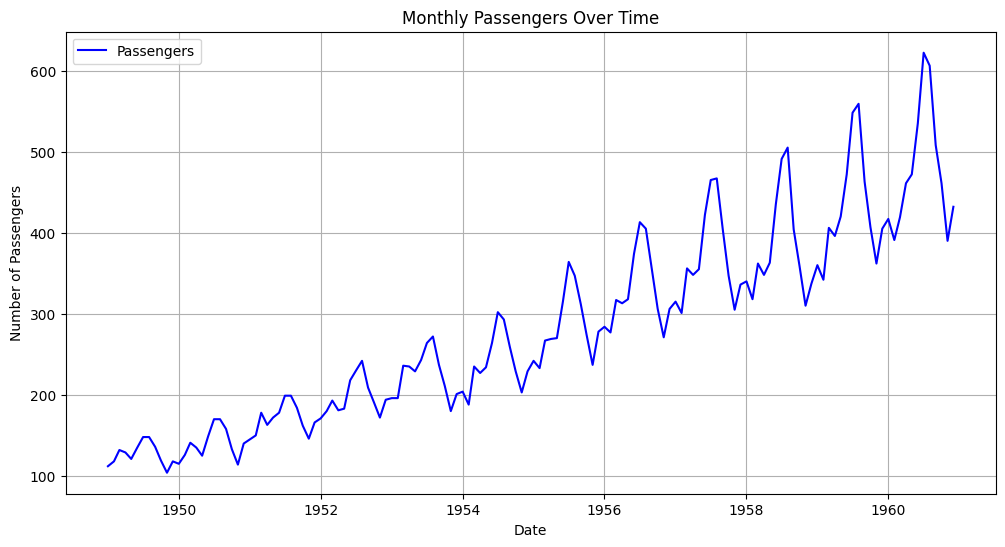

In [11]:
# Line plot of passengers over time
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Passengers'], label='Passengers', color='blue')
plt.title('Monthly Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid()
plt.show()


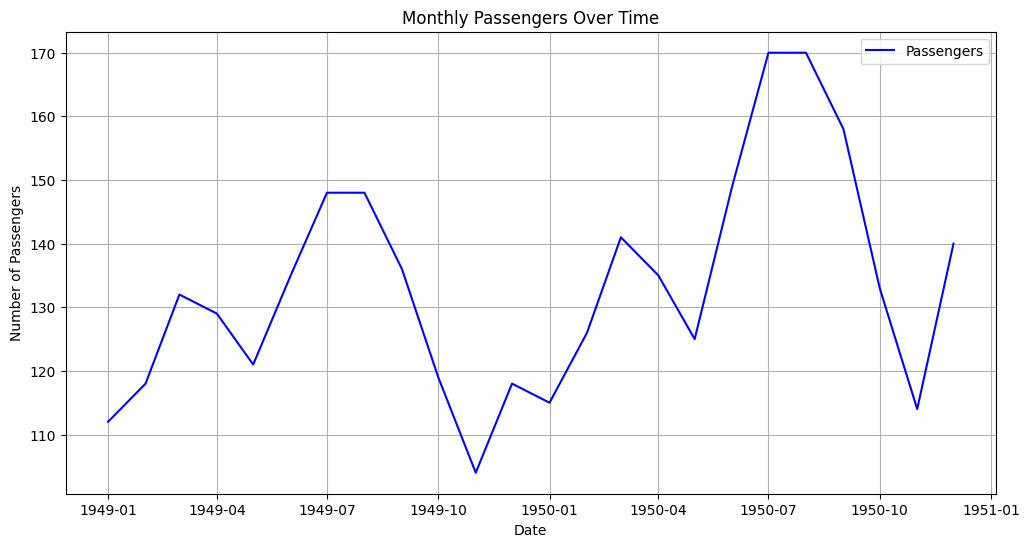

In [12]:
# Line plot of passengers over time
plt.figure(figsize=(12, 6))
plt.plot(data.index[:24], data['Passengers'][:24], label='Passengers', color='blue')
plt.title('Monthly Passengers Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.legend()
plt.grid()
plt.show()

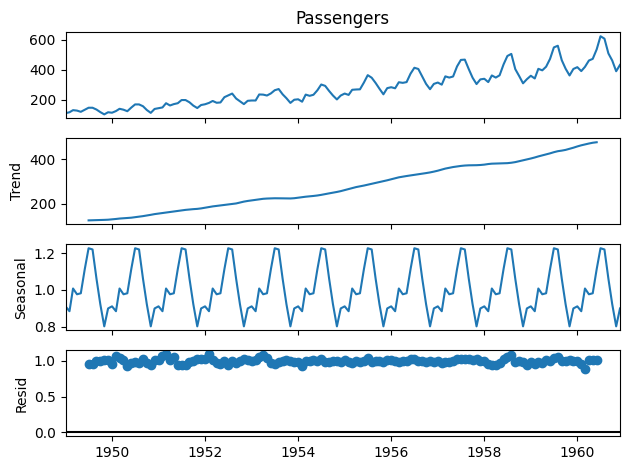

In [13]:
# Decompose the time series
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['Passengers'], model='multiplicative', period=12)
decomposition.plot()
plt.show()


In [14]:
from statsmodels.tsa.stattools import adfuller

In [15]:
# Perform ADF Test
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value}')
    if result[1] <= 0.05:
        print("The time series is stationary.")
    else:
        print("The time series is not stationary.")

print("\nADF Test Results:")
adf_test(data['Passengers'])


ADF Test Results:
ADF Statistic: 0.8153688792060463
p-value: 0.991880243437641
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
The time series is not stationary.


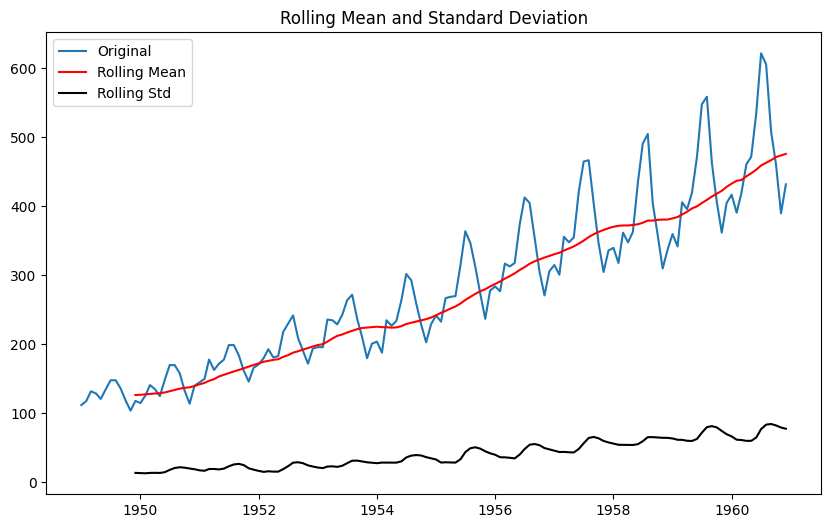

In [16]:
# Plot rolling mean and standard deviation
rolling_mean = data['Passengers'].rolling(window=12).mean()
rolling_std = data['Passengers'].rolling(window=12).std()

plt.figure(figsize=(10, 6))
plt.plot(data['Passengers'], label='Original')
plt.plot(rolling_mean, label='Rolling Mean', color='red')
plt.plot(rolling_std, label='Rolling Std', color='black')
plt.title('Rolling Mean and Standard Deviation')
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

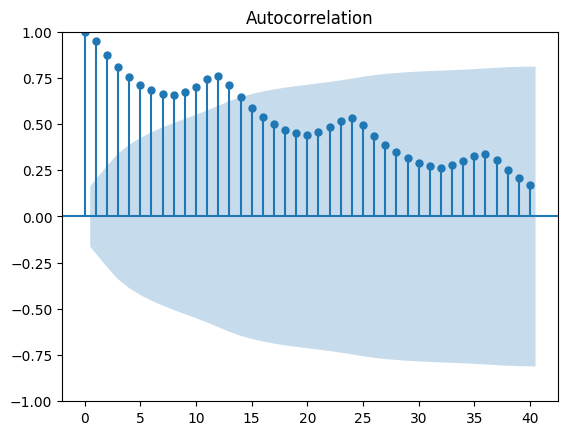

<Figure size 1000x600 with 0 Axes>

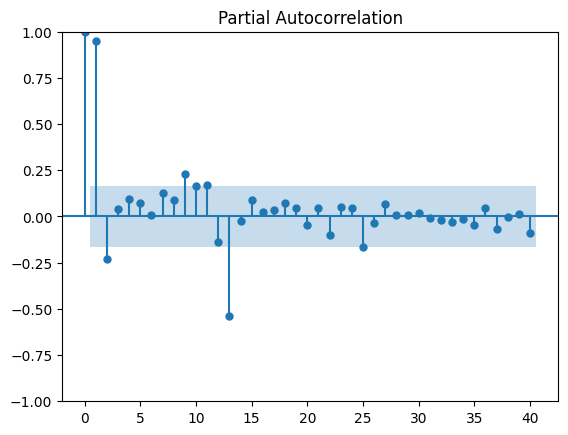

In [17]:
# Autocorrelation and Partial Autocorrelation Plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10, 6))
plot_acf(data['Passengers'], lags=40)
plt.show()

plt.figure(figsize=(10, 6))
plot_pacf(data['Passengers'], lags=40)
plt.show()

Observations and Inferences from ADF Test, ACF, and PACF
1. Augmented Dickey-Fuller (ADF) Test
ADF Statistic: 0.815
p-value: 0.9918
Critical Values:
1%: -3.482
5%: -2.884
10%: -2.579
Interpretation:
The ADF Statistic (0.815) is greater than all critical values (at 1%, 5%, and 10% significance levels).
The p-value (0.9918) is much greater than 0.05.
This indicates that the null hypothesis (the series is non-stationary) cannot be rejected.
Inference:
The time series is not stationary, and further transformations (e.g., differencing or detrending) are needed to achieve stationarity.
2. Autocorrelation Function (ACF) Plot
The ACF shows significant positive correlations at multiple lags, gradually decaying over time.
The decay suggests the presence of seasonality and trend in the data.
Inference:
The series has a strong autocorrelation structure, indicating seasonality with a yearly pattern.
Differencing or seasonal decomposition may help address these patterns for stationarity.
3. Partial Autocorrelation Function (PACF) Plot
The PACF has a strong spike at lag 1 and decreases sharply afterward.
Some minor spikes at higher lags indicate potential seasonal effects.
Inference:
A strong lag-1 spike suggests an AR(1) component might be significant in a potential ARIMA or SARIMA model.
Seasonal differencing may be required to address periodic patterns in the series.
Next Steps
Apply first-order differencing to remove the trend and recheck for stationarity using the ADF test.
Consider seasonal differencing if the ADF test on the differenced series still indicates non-stationarity.
Use ACF and PACF plots post-transformation to identify appropriate ARIMA/SARIMA parameters for modeling.

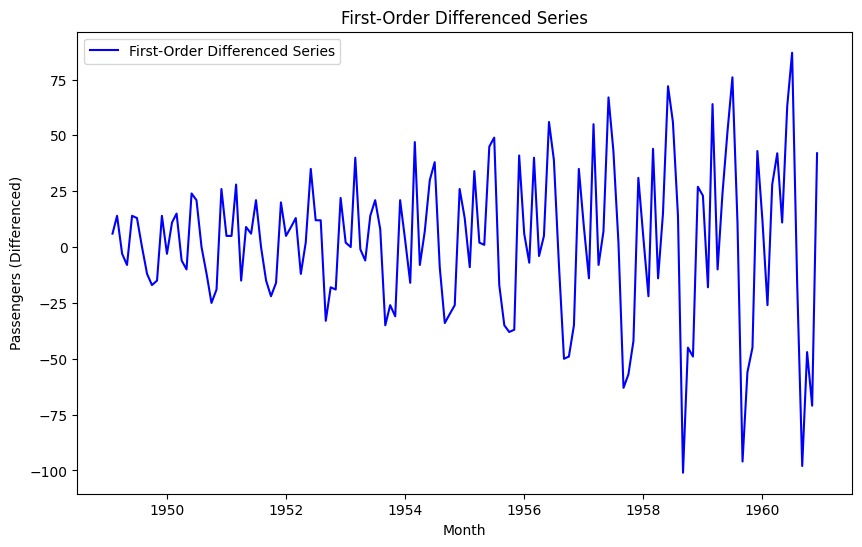


ADF Test Results on Differenced Series:
ADF Statistic: -2.8292668241699923
p-value: 0.054213290283826474
Critical Values:
   1%: -3.4816817173418295
   5%: -2.8840418343195267
   10%: -2.578770059171598
The time series is not stationary.


In [18]:

# First-Order Differencing
data['Passengers_diff'] = data['Passengers'].diff()
data.dropna(inplace=True)

# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Passengers_diff'], label='First-Order Differenced Series', color='blue')
plt.title('First-Order Differenced Series')
plt.xlabel('Month')
plt.ylabel('Passengers (Differenced)')
plt.legend()
plt.show()

# Recheck Stationarity with ADF Test
print("\nADF Test Results on Differenced Series:")
adf_test(data['Passengers_diff'])



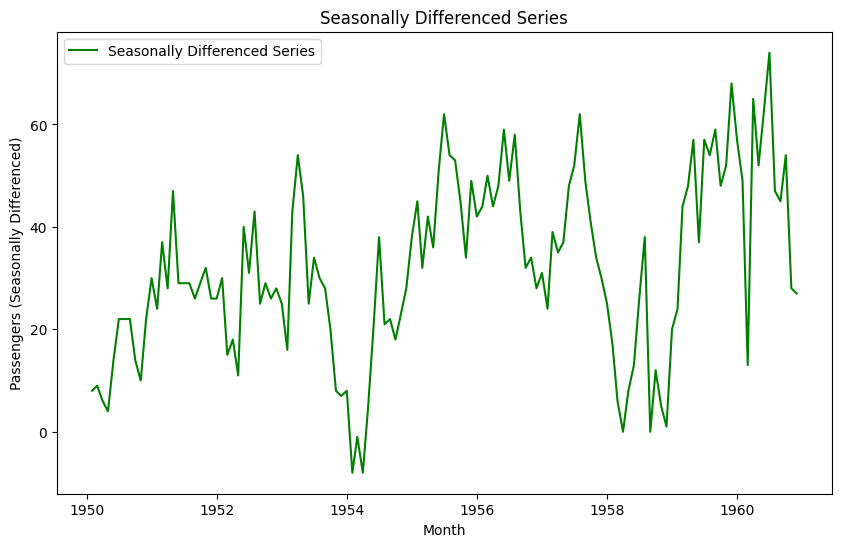


ADF Test Results on Seasonally Differenced Series:
ADF Statistic: -3.375189099719881
p-value: 0.011834318115889409
Critical Values:
   1%: -3.482087964046026
   5%: -2.8842185101614626
   10%: -2.578864381347275
The time series is stationary.


<Figure size 1000x600 with 0 Axes>

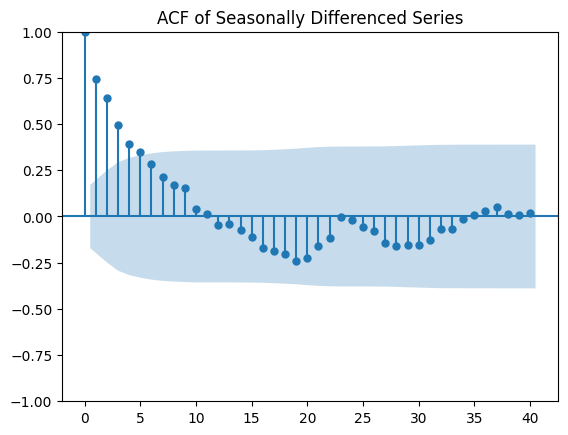

<Figure size 1000x600 with 0 Axes>

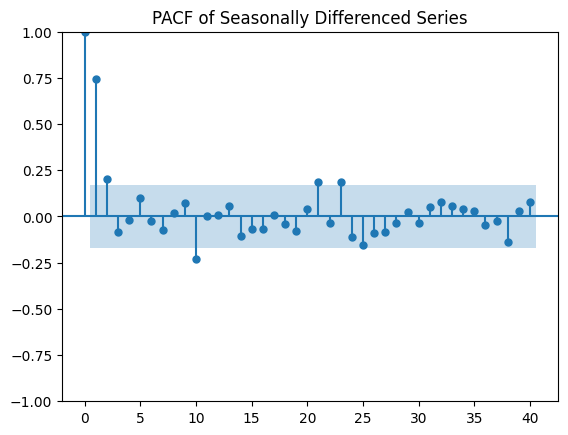

In [19]:
# Seasonal Differencing 
data['Passengers_seasonal_diff'] = data['Passengers'].diff(12)  # a yearly seasonality
data.dropna(inplace=True)

# Plot the seasonally differenced series
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Passengers_seasonal_diff'], label='Seasonally Differenced Series', color='green')
plt.title('Seasonally Differenced Series')
plt.xlabel('Month')
plt.ylabel('Passengers (Seasonally Differenced)')
plt.legend()
plt.show()

# Recheck Stationarity with ADF Test (after seasonal differencing)
print("\nADF Test Results on Seasonally Differenced Series:")
adf_test(data['Passengers_seasonal_diff'])

# Plot ACF and PACF for ARIMA/SARIMA parameter selection
plt.figure(figsize=(10, 6))
plot_acf(data['Passengers_seasonal_diff'], lags=40)
plt.title('ACF of Seasonally Differenced Series')
plt.show()

plt.figure(figsize=(10, 6))
plot_pacf(data['Passengers_seasonal_diff'], lags=40)
plt.title('PACF of Seasonally Differenced Series')
plt.show()


Observations and Inferences
1. First-Order Differenced Series
The first-order differenced series shows a reduction in trend compared to the original series.
However, the ADF test result indicates the series is still not stationary:
ADF Statistic: -2.829
p-value: 0.054 (greater than 0.05).
This suggests that seasonal patterns remain unaddressed, necessitating seasonal differencing.
2. Seasonally Differenced Series
The seasonally differenced series removes both trend and seasonality, making the fluctuations around the mean more stable.
The ADF test confirms the series is stationary:
ADF Statistic: -3.375
p-value: 0.0118 (less than 0.05).
Critical values show the series has become stationary at a 5% significance level.
3. ACF Plot (Seasonally Differenced Series)
The ACF shows:
A significant spike at lag 1, indicating a strong short-term autocorrelation.
Seasonal spikes at lags 12, 24, etc., confirming yearly seasonality in the data.
Suggests the inclusion of a seasonal moving average (SMA) component in the model.
4. PACF Plot (Seasonally Differenced Series)
The PACF plot shows:
A strong spike at lag 1, indicating the need for an AR(1) term.
A few other minor spikes suggest potential seasonal autoregressive (SAR) components.
Suggested ARIMA/SARIMA Model Parameters
Based on the differenced series, ACF, and PACF:

Non-Seasonal Parameters (p, d, q):
p = 1 (AR(1) based on PACF spike).
d = 1 (one order differencing to remove trend).
q = 1 (MA(1) based on ACF spike).
Seasonal Parameters (P, D, Q, s):
P = 1 (SAR(1) based on PACF spike at lag 12).
D = 1 (seasonal differencing already applied).
Q = 1 (SMA(1) based on ACF spike at lag 12).
s = 12 (seasonality is yearly).


e:\IIITA_INTERNSHIP\Timeseries_forecasting_using_LSTM\Project_Code\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
e:\IIITA_INTERNSHIP\Timeseries_forecasting_using_LSTM\Project_Code\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  104
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -291.100
Date:                            Thu, 21 May 2026   AIC                            592.201
Time:                                    22:19:43   BIC                            603.920
Sample:                                02-01-1950   HQIC                           596.888
                                     - 09-01-1958                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6721      0.166      4.053      0.000       0.347       0.997
ma.L1         -0.8639      0.134   

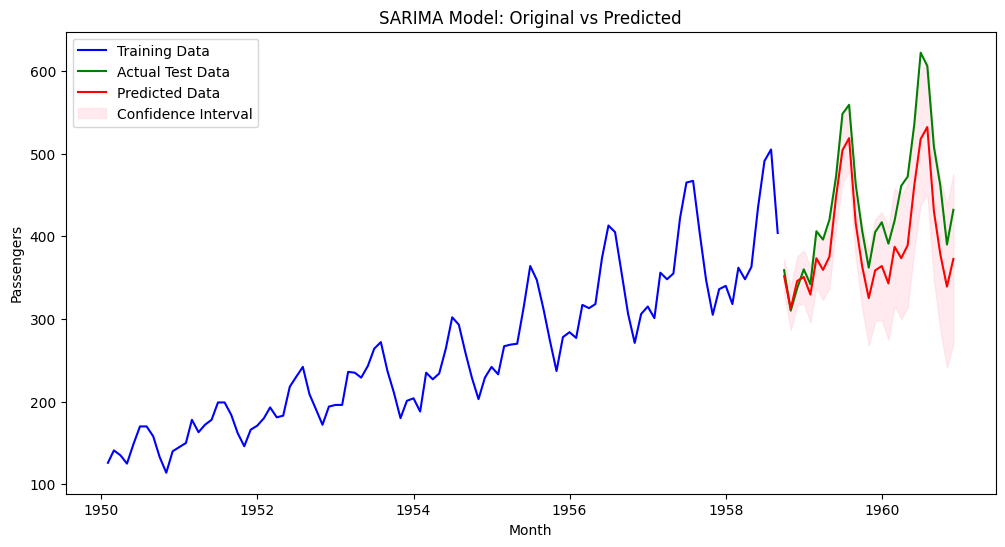

Mean Absolute Error (MAE): 46.766773465546244
Mean Squared Error (MSE): 2889.4697811588035
Root Mean Squared Error (RMSE): 53.75378852842657


In [20]:
#  Train-Test Split
train_size = int(len(data) * 0.8)  # 80% for training
train = data['Passengers'][:train_size]
test = data['Passengers'][train_size:]

# Define the SARIMA Model
model = SARIMAX(train, 
                order=(1, 1, 1), # order=(p, d, q) here 'd' is  regular differencing 
                seasonal_order=(1, 1, 1, 12), #seasonal_order=(P, D, Q, seasonality) here 'D' is seasonal differencing
                enforce_stationarity=False, 
                enforce_invertibility=False)

sarima_model = model.fit(disp=False)

# Model Summary
print(sarima_model.summary())

# Forecast on the Test Set
forecast = sarima_model.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

# Plot Original, Predicted, and Confidence Interval
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Test Data', color='green')
plt.plot(test.index, forecast_mean, label='Predicted Data', color='red')
plt.fill_between(test.index, 
                 forecast_conf_int.iloc[:, 0], 
                 forecast_conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title('SARIMA Model: Original vs Predicted')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

# Evaluate Model Performance

mse = mean_squared_error(test, forecast_mean)
mae = mean_absolute_error(test, forecast_mean)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")


In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

# Prepare the data for Nixtla
# Nixtla expects columns: unique_id, ds (date), and y (value)

df_nixtla = data.reset_index()[['Month', 'Passengers']].rename(columns={'Month': 'ds', 'Passengers': 'y'})

df_nixtla['unique_id'] = 'Passengers'  # Single time series ID
print(df_nixtla.head())

# Split the data into train and test sets
train_size = int(len(df_nixtla) * 0.8)
train = df_nixtla.iloc[:train_size]
test = df_nixtla.iloc[train_size:]


e:\IIITA_INTERNSHIP\Timeseries_forecasting_using_LSTM\Project_Code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (e:\IIITA_INTERNSHIP\Timeseries_forecasting_using_LSTM\Project_Code\venv\Lib\site-packages\scipy\_lib\_util.py)

: 

In [ ]:
# ETS(A,M,A)

In [ ]:
# Define models to fit
models = [AutoARIMA(season_length=12), AutoETS(season_length=12)]

# Initialize StatsForecast
sf = StatsForecast(models=models, freq='M')

# Fit models on the training set
sf.fit(train)


In [ ]:
# Forecast for the test period length
forecast_horizon = len(test)
forecast = sf.predict(h=forecast_horizon)


# Merge actual test data with predictions
test = test.reset_index(drop=True)
forecast['ds'] = test['ds']
forecast['actual'] = test['y']


plt.figure(figsize=(12, 6))
plt.plot(train['ds'], train['y'], label='Training Data', color='blue')
plt.plot(test['ds'], test['y'], label='Actual Test Data', color='green')
plt.plot(forecast['ds'], forecast['AutoARIMA'], label='AutoARIMA Forecast', color='red')
plt.plot(forecast['ds'], forecast['AutoETS'], label='ETS Forecast', color='orange')
plt.title('Nixtla: AutoARIMA and ETS Forecasts')
plt.xlabel('Date')
plt.ylabel('Passengers')
plt.legend()
plt.show()


In [ ]:
# Calculate metrics for AutoARIMA
mse_autoarima = mean_squared_error(forecast['actual'], forecast['AutoARIMA'])
mae_autoarima = mean_absolute_error(forecast['actual'], forecast['AutoARIMA'])
rmse_autoarima = mse_autoarima**0.5

# Calculate metrics for ETS
mse_ets = mean_squared_error(forecast['actual'], forecast['AutoETS'])
mae_ets = mean_absolute_error(forecast['actual'], forecast['AutoETS'])
rmse_ets = mse_ets**0.5

print("\nAutoARIMA Performance:")
print(f"MAE: {mae_autoarima}, MSE: {mse_autoarima}, RMSE: {rmse_autoarima}")

print("\nETS Performance:")
print(f"MAE: {mae_ets}, MSE: {mse_ets}, RMSE: {rmse_ets}")


### **LSTM**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [ ]:
lstm_data  = data.copy()

In [ ]:
# Prepare data
values = lstm_data['Passengers'].values.reshape(-1, 1)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

# Create sequences for LSTM
def create_sequences(data, time_steps=12):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
        y.append(data[i + time_steps])
    return np.array(X), np.array(y)
# X[100, 110, 120] y [130]
time_steps = 12
X, y = create_sequences(scaled_values, time_steps)

# Split into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model
model = Sequential([
    LSTM(50, activation='relu', input_shape=(time_steps, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)


In [ ]:

# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Inverse scale predictions and actual values
y_train_pred = scaler.inverse_transform(y_train_pred)
y_train = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_pred = scaler.inverse_transform(y_test_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(data.index[:len(y_train)], y_train, label='Training Data')
plt.plot(data.index[len(y_train):(len(y_train) + len(y_test))], y_test, label='Actual Test Data', color='green')
plt.plot(data.index[len(y_train):(len(y_train) + len(y_test))], y_test_pred, label='Predicted Test Data', color='red')
plt.title('LSTM Model: Original vs Predicted')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.show()

# Evaluate performance
mse = mean_squared_error(y_test, y_test_pred)
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
